# Lab 10: Time Series Analysis

## Dataset: Daily Minimum Temperatures in Melbourne, Australia

This lab explores a public time series dataset containing daily minimum temperatures recorded in Melbourne, Australia from 1981 to 1990. The goal is to use Pandas and visualizations to understand trends, rolling averages, resampling, seasonality, possible outliers, and suitable forecasting methods.

Dataset source:  
https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv

## AI Tool Usage

For this lab, I used ChatGPT as the AI tool to help guide the time series analysis.

### AI Prompt Used

"Help me find a public time series dataset suitable for a Pandas lab. The dataset should include a date column and a numeric value column so I can practice datetime conversion, setting the date as an index, plotting time series trends, rolling averages, resampling, seasonal pattern analysis, anomaly detection, and forecasting model recommendations."

### AI Insight

ChatGPT recommended the Daily Minimum Temperatures in Melbourne dataset because it is a clean public time series dataset with daily observations over multiple years. The dataset is appropriate for learning time series analysis because it includes a date column, a numeric temperature column, visible seasonal patterns, and enough observations to support rolling averages and monthly resampling.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots clearly
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the public time series dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Display the first 10 rows

df.head(10)

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
5,1981-01-06,15.8
6,1981-01-07,15.8
7,1981-01-08,17.4
8,1981-01-09,21.8
9,1981-01-10,20.0


In [4]:
# Display dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


## Convert Date Column to Datetime Format

The `Date` column needs to be converted from a regular object/string column into a Pandas datetime format. This allows Pandas to recognize the values as dates and makes time series operations possible.

In [5]:
# Convert the Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

# Confirm the data types
df.dtypes

Date    datetime64[ns]
Temp           float64
dtype: object

## Set Date Column as the DataFrame Index

After converting the `Date` column to datetime format, it is set as the index. This makes it easier to plot, resample, and analyze the data by time period.

In [6]:
# Set Date as the index

df = df.set_index("Date")

# Display the first 10 rows after setting datetime index
df.head(10)

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
1981-01-06,15.8
1981-01-07,15.8
1981-01-08,17.4
1981-01-09,21.8


In [7]:
# Confirm the index type and dataset structure

print("Index type:", type(df.index))
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Total records:", len(df))

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Start date: 1981-01-01 00:00:00
End date: 1990-12-31 00:00:00
Total records: 3650


## Time Series Line Graph

The first visualization shows daily minimum temperature values over time. This helps identify the overall pattern, long-term behavior, and seasonal movement in the dataset.

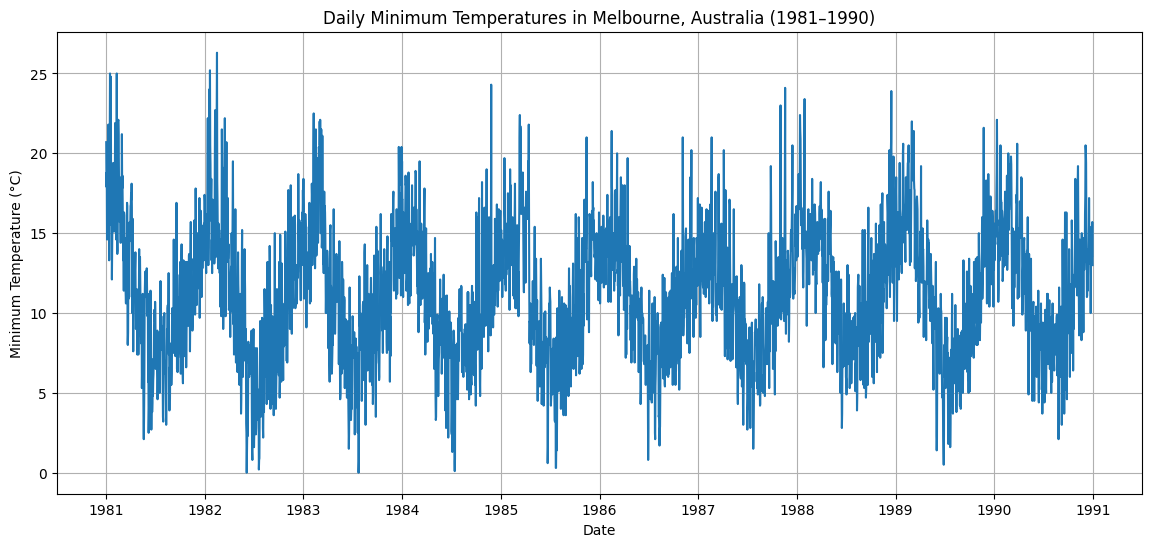

In [8]:
# Plot the daily minimum temperature time series

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Temp"])

plt.title("Daily Minimum Temperatures in Melbourne, Australia (1981–1990)")
plt.xlabel("Date")
plt.ylabel("Minimum Temperature (°C)")
plt.grid(True)

plt.show()

## AI-Assisted Interpretation of the Line Graph

The line graph shows clear seasonal patterns in daily minimum temperatures. Temperatures rise and fall repeatedly across the years, which suggests annual seasonality. Warmer minimum temperatures generally occur during the summer months, while lower minimum temperatures occur during the winter months. The values fluctuate daily, so the graph appears noisy at the daily level. Because of this daily variation, rolling averages can help smooth the line and make the larger pattern easier to understand.

## Rolling Average Analysis

Rolling averages smooth daily fluctuations by calculating the average value over a moving window of time. In this lab, a 7-day rolling average and a 30-day rolling average are used.

The 7-day rolling average smooths short-term daily noise, while the 30-day rolling average makes the broader monthly trend easier to see.

In [9]:
# Create rolling average columns

df["Temp_7_Day_Rolling"] = df["Temp"].rolling(window=7).mean()
df["Temp_30_Day_Rolling"] = df["Temp"].rolling(window=30).mean()

# Display the first 35 rows to show rolling average calculations
df.head(35)

,Temp,Temp_7_Day_Rolling,Temp_30_Day_Rolling
Date,,,
1981-01-01,20.7,NaN,NaN
1981-01-02,17.9,NaN,NaN
1981-01-03,18.8,NaN,NaN
1981-01-04,14.6,NaN,NaN
1981-01-05,15.8,NaN,NaN
1981-01-06,15.8,NaN,NaN
1981-01-07,15.8,17.057143,NaN
1981-01-08,17.4,16.585714,NaN
1981-01-09,21.8,17.142857,NaN


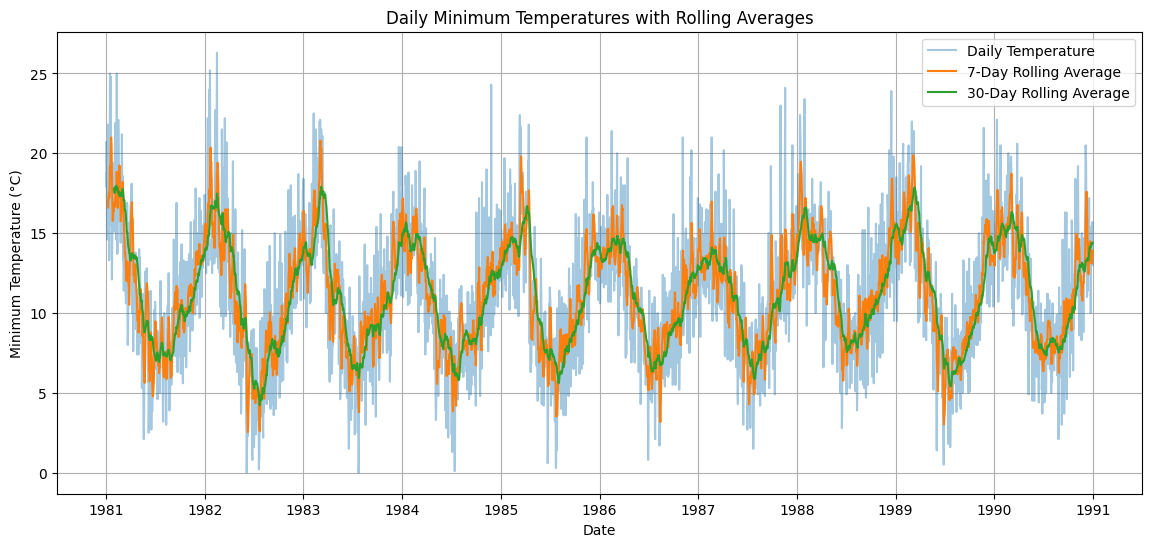

In [10]:
# Plot original temperature with 7-day and 30-day rolling averages

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Temp"], label="Daily Temperature", alpha=0.4)
plt.plot(df.index, df["Temp_7_Day_Rolling"], label="7-Day Rolling Average")
plt.plot(df.index, df["Temp_30_Day_Rolling"], label="30-Day Rolling Average")

plt.title("Daily Minimum Temperatures with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Minimum Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

## AI-Assisted Interpretation of Rolling Averages

The rolling average plot makes the seasonal temperature pattern easier to see. The daily temperature line has many short-term fluctuations, but the 7-day rolling average smooths weekly variation. The 30-day rolling average is even smoother and highlights the broader seasonal cycle.

The pattern shows repeated annual increases and decreases in temperature. This confirms that the dataset contains strong yearly seasonality. Rolling averages are useful here because they reduce daily noise and allow the overall trend to become more visible.

## Resampling the Time Series

Resampling changes the frequency of time series data. Since this dataset contains daily temperature observations, we can resample it into weekly or monthly averages.

Weekly resampling helps reduce daily noise while still preserving short-term patterns. Monthly resampling provides a clearer view of longer-term seasonal trends.

In [11]:
# Resample the data by week and month

weekly_temp = df["Temp"].resample("W").mean()
monthly_temp = df["Temp"].resample("M").mean()

print("Weekly resampled data:")
display(weekly_temp.head(10))

print("Monthly resampled data:")
display(monthly_temp.head(10))

Weekly resampled data:


C:\Users\dubey\AppData\Local\Temp\ipykernel_40712\3282072439.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["Temp"].resample("M").mean()


Date
1981-01-04    18.000000
1981-01-11    17.542857
1981-01-18    20.371429
1981-01-25    15.771429
1981-02-01    16.657143
1981-02-08    17.957143
1981-02-15    18.571429
1981-02-22    17.300000
1981-03-01    17.242857
1981-03-08    15.271429
Freq: W-SUN, Name: Temp, dtype: float64

Monthly resampled data:


Date
1981-01-31    17.712903
1981-02-28    17.678571
1981-03-31    13.500000
1981-04-30    12.356667
1981-05-31     9.490323
1981-06-30     7.306667
1981-07-31     7.577419
1981-08-31     7.238710
1981-09-30    10.143333
1981-10-31    10.087097
Freq: ME, Name: Temp, dtype: float64

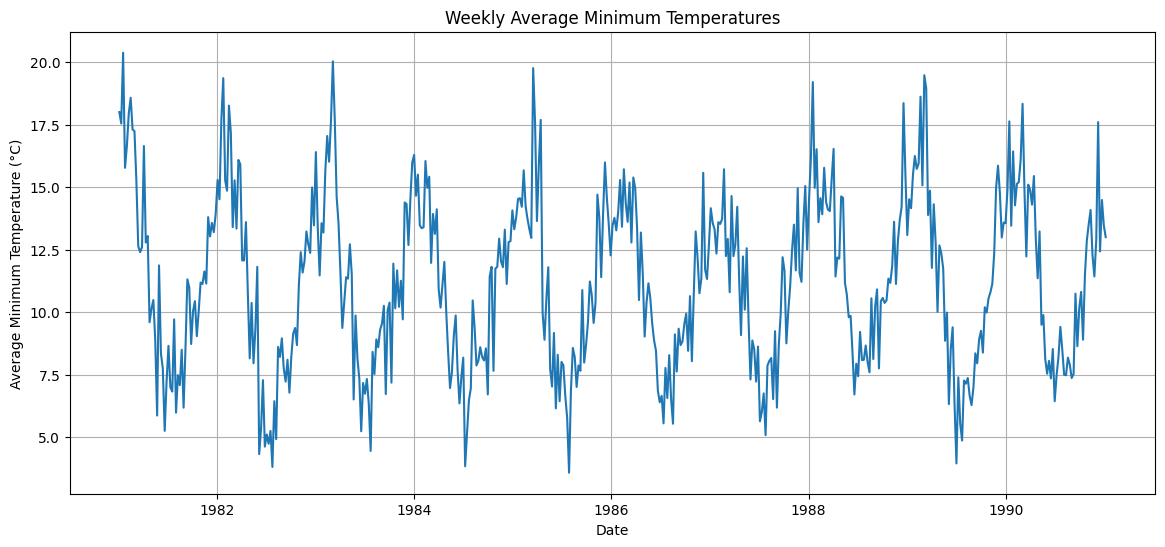

In [12]:
# Plot weekly average temperature

plt.figure(figsize=(14, 6))

plt.plot(weekly_temp.index, weekly_temp)

plt.title("Weekly Average Minimum Temperatures")
plt.xlabel("Date")
plt.ylabel("Average Minimum Temperature (°C)")
plt.grid(True)

plt.show()

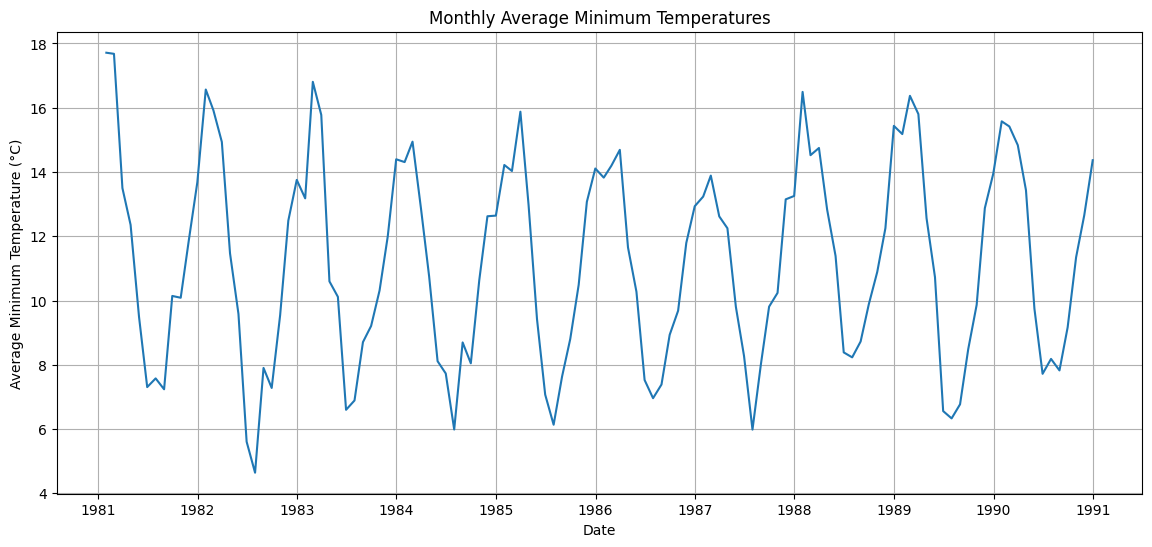

In [13]:
# Plot monthly average temperature

plt.figure(figsize=(14, 6))

plt.plot(monthly_temp.index, monthly_temp)

plt.title("Monthly Average Minimum Temperatures")
plt.xlabel("Date")
plt.ylabel("Average Minimum Temperature (°C)")
plt.grid(True)

plt.show()

## AI-Assisted Interpretation of Resampling

Resampling the dataset makes the trend easier to interpret. The weekly average reduces daily variation but still shows short-term movement. The monthly average creates a smoother time series and clearly displays the annual seasonal cycle.

The monthly plot shows repeated peaks and valleys across the years. This indicates that minimum temperatures follow a strong yearly pattern. Resampling is useful because it transforms noisy daily data into a clearer summary at a higher time level.

## Seasonal Patterns, Outliers, and Anomalies

Time series data often contains repeating seasonal patterns. In this dataset, temperature is expected to follow an annual seasonal cycle because weather changes throughout the year.

We can also visually inspect the data for unusual values, sudden spikes, or possible anomalies.

In [14]:
# Create year and month columns for seasonal analysis

df["Year"] = df.index.year
df["Month"] = df.index.month

df.head()

,Temp,Temp_7_Day_Rolling,Temp_30_Day_Rolling,Year,Month
Date,,,,,
1981-01-01,20.7,NaN,NaN,1981,1
1981-01-02,17.9,NaN,NaN,1981,1
1981-01-03,18.8,NaN,NaN,1981,1
1981-01-04,14.6,NaN,NaN,1981,1
1981-01-05,15.8,NaN,NaN,1981,1


In [15]:
# Calculate average temperature by month

monthly_seasonality = df.groupby("Month")["Temp"].mean()

monthly_seasonality

Month
1     15.030323
2     15.373759
3     14.565484
4     12.088333
5      9.866452
6      7.278333
7      6.692581
8      7.891290
9      8.976333
10    10.309355
11    12.479667
12    13.851948
Name: Temp, dtype: float64

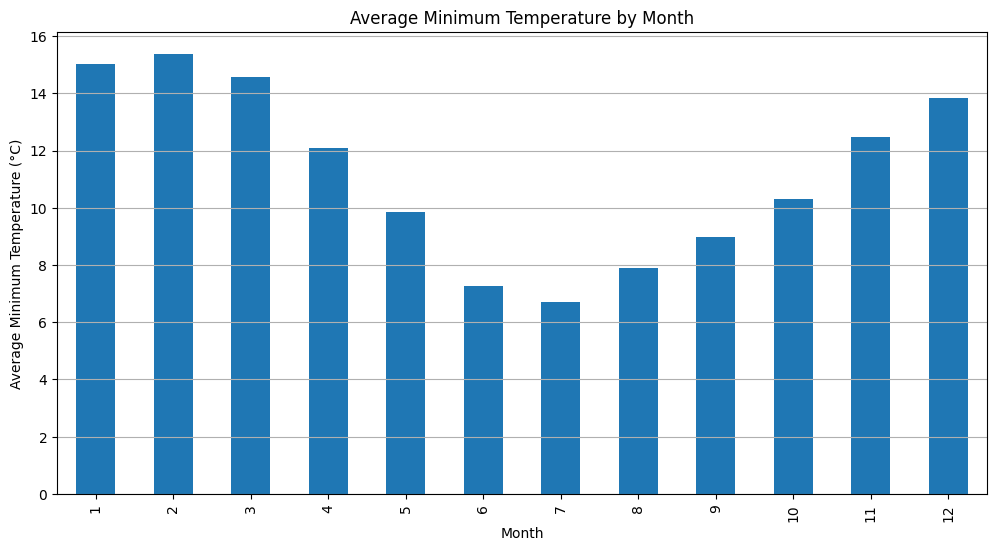

In [16]:
# Plot average temperature by month to check seasonality

plt.figure(figsize=(12, 6))

monthly_seasonality.plot(kind="bar")

plt.title("Average Minimum Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Minimum Temperature (°C)")
plt.grid(axis="y")

plt.show()

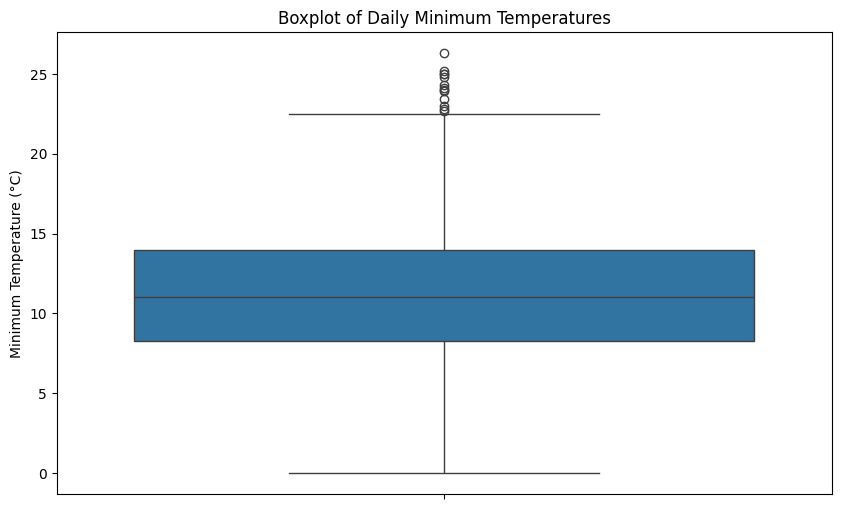

In [17]:
# Visual inspection of possible outliers using a boxplot

plt.figure(figsize=(10, 6))

sns.boxplot(y=df["Temp"])

plt.title("Boxplot of Daily Minimum Temperatures")
plt.ylabel("Minimum Temperature (°C)")

plt.show()

In [18]:
# Identify possible outliers using the IQR method

Q1 = df["Temp"].quantile(0.25)
Q3 = df["Temp"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Temp"] < lower_bound) | (df["Temp"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of possible outliers:", len(outliers))

outliers.head(10)

Lower bound: -0.24999999999999822
Upper bound: 22.549999999999997
Number of possible outliers: 13


,Temp,Temp_7_Day_Rolling,Temp_30_Day_Rolling,Year,Month
Date,,,,,
1981-01-15,25.0,19.214286,NaN,1981,1
1981-01-18,24.8,20.371429,NaN,1981,1
1981-02-09,25.0,18.842857,17.883333,1981,2
1982-01-17,24.0,17.728571,15.153333,1982,1
1982-01-20,25.2,18.542857,16.070000,1982,1
1982-02-08,22.7,16.014286,16.966667,1982,2
1982-02-14,22.8,18.257143,17.133333,1982,2
1982-02-15,26.3,18.771429,17.483333,1982,2
1984-11-26,24.3,13.157143,12.503333,1984,11


## AI-Assisted Interpretation of Seasonality and Outliers

The monthly average temperature chart shows a strong seasonal pattern. Because the dataset is from Melbourne, Australia, the warmer minimum temperatures occur around the Australian summer months, especially January and February. Cooler minimum temperatures occur around the Australian winter months, especially June, July, and August.

The boxplot and IQR method help identify possible outliers. These values may represent unusually cold or unusually warm days. In time series analysis, outliers are not always errors. They may reflect real weather events, such as extreme cold fronts or heat waves. Therefore, it is important to inspect outliers carefully before removing them.

## AI Prompt: Forecasting Model Recommendations

### AI Prompt Used

"Based on a daily temperature time series dataset with clear annual seasonality, daily noise, rolling averages, and monthly resampling, what forecasting models or techniques would be suitable? Please explain the options in beginner-friendly language."

## AI-Assisted Forecasting Model Recommendations

For this dataset, several forecasting methods would be suitable:

1. **Moving Average Forecasting**  
   A moving average model can be used as a simple baseline. It predicts future values using the average of recent observations. This is easy to understand but may not capture seasonality well.

2. **Exponential Smoothing**  
   Exponential smoothing gives more weight to recent observations. A seasonal version of exponential smoothing, such as Holt-Winters, would be useful because the temperature data has a repeated yearly pattern.

3. **ARIMA or Seasonal ARIMA (SARIMA)**  
   ARIMA models are commonly used for time series forecasting. Since this dataset shows strong yearly seasonality, SARIMA would be more appropriate than a basic ARIMA model because SARIMA can include seasonal terms.

4. **Prophet**  
   Prophet is useful for time series with trend and seasonality. It can handle yearly seasonality and is often easier to use than manually tuning SARIMA.

5. **Machine Learning Models**  
   Models such as Random Forest, XGBoost, or neural networks could also be used if date-based features are created, such as month, day of year, lag values, and rolling averages. These methods may perform well but require additional feature engineering.

Overall, a good next step would be to start with a simple moving average baseline, then compare it with Holt-Winters or SARIMA because the dataset has strong annual seasonality.

## Final Summary

In this lab, I explored a daily time series dataset containing minimum temperatures in Melbourne, Australia from 1981 to 1990. The dataset included a date column and a temperature column, which made it suitable for practicing time series analysis in Pandas.

First, I loaded the dataset into a Pandas DataFrame and displayed the first 10 rows and structure of the data. I converted the `Date` column into Pandas datetime format and set it as the DataFrame index. This allowed the dataset to be analyzed as a proper time series.

The initial line graph showed that daily minimum temperatures fluctuate frequently, but there is also a clear repeating seasonal pattern. Temperatures rise and fall across each year, which suggests strong annual seasonality. Rolling averages helped smooth the daily noise. The 7-day rolling average reduced short-term variation, while the 30-day rolling average made the broader seasonal trend easier to see.

I also resampled the data into weekly and monthly averages. The weekly average reduced daily variation, while the monthly average provided a clearer view of long-term seasonal changes. The monthly chart showed repeated peaks and valleys across the years, confirming that temperature follows a yearly cycle.

Seasonal analysis showed that warmer minimum temperatures generally occurred in January and February, while cooler minimum temperatures occurred around June, July, and August. This pattern makes sense because the dataset is from Melbourne, Australia, where seasons are opposite from the Northern Hemisphere. The boxplot and IQR method were used to identify possible outliers. These outliers may represent real unusual weather events rather than data errors.

ChatGPT assisted by helping select a suitable public time series dataset, guiding the analysis steps, explaining rolling averages and resampling, identifying seasonal patterns, and recommending possible forecasting techniques. The AI guidance helped connect the Python outputs to meaningful time series insights.

For future analysis, I would build forecasting models and compare their performance. I would begin with a simple moving average baseline, then test Holt-Winters exponential smoothing and SARIMA because the dataset has clear yearly seasonality. I would also explore whether adding features such as month, day of year, lag values, and rolling averages improves forecasting accuracy.